## 준비

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.autograd import Variable
import torch.nn.functional as F

import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset

In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
data_dir = '/content/drive/MyDrive/boaz/mm_pytorch/data'

train_dataset = torchvision.datasets.FashionMNIST(root=data_dir, transform=transforms.Compose([transforms.ToTensor()]), download=True)
test_dataset = torchvision.datasets.FashionMNIST(root=data_dir, train=False, transform=transforms.Compose([transforms.ToTensor()]), download=True)

In [6]:
# 데이터 사이즈 확인
print(len(train_dataset))
image, label = train_dataset[0]
print(image.size())

60000
torch.Size([1, 28, 28])


In [7]:
train_loader = DataLoader(dataset=train_dataset, batch_size=100)
test_loader = DataLoader(dataset=test_dataset, batch_size=100)

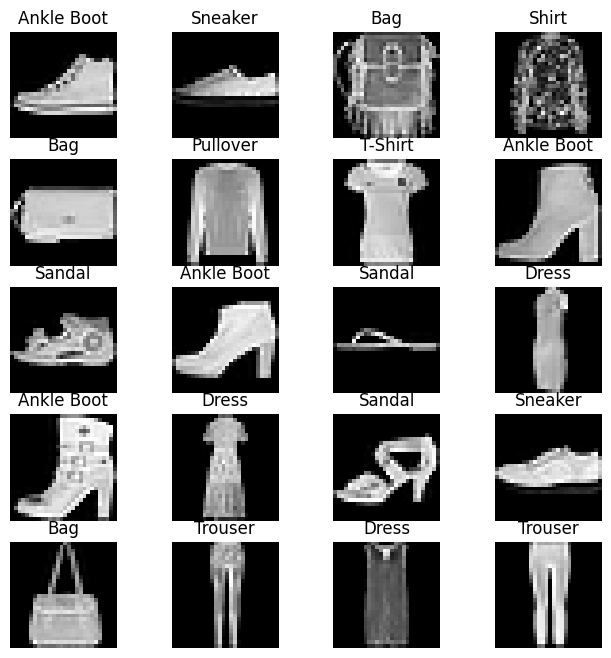

In [8]:
# 데이터 시각화
labels_map = {0 : 'T-Shirt', 1 : 'Trouser', 2 : 'Pullover', 3 : 'Dress', 4 : 'Coat', 5 : 'Sandal', 6 : 'Shirt' , 7 : 'Sneaker' , 8 : 'Bag' ,
              9 : 'Ankle Boot'}

fig = plt.figure(figsize=(8,8))
columns = 4
rows = 5
for i in range(1, columns*rows +1):
    img_xy = np.random.randint(len(train_dataset)); # 랜덤 인덱스
    img = train_dataset[img_xy][0][0,:,:]
    fig.add_subplot(rows, columns, i)               # figure 칸 나누기
    plt.title(labels_map[train_dataset[img_xy][1]])
    plt.axis('off')
    plt.imshow(img, cmap='gray')
plt.show()

## DNN

In [9]:
class FashionDNN(nn.Module):
  def __init__(self):
    super(FashionDNN, self).__init__()
    self.fc1 = nn.Linear(in_features = 784, out_features = 256)
    self.drop = nn.Dropout(0.25)
    self.fc2 = nn.Linear(in_features = 256, out_features = 128)
    self.fc3 = nn.Linear(in_features = 128, out_features = 10)

  def forward(self, input_data):
    out = input_data.view(-1, 784) # 행벡터 전환
    out = F.relu(self.fc1(out))    # Dense Layer1 - 활성화함수(relu) 통과 (은닉층 시작)
    out = self.drop(out)           # Dropout(0.25)
    out = F.relu(self.fc2(out))    # Dense Layer2 - 활성화함수(relu) 통과 (은닉층 끝)
    out = self.fc3(out)            # 출력층
    return out

In [10]:
learning_rate = 0.001;
model = FashionDNN();
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
print(model)

FashionDNN(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (drop): Dropout(p=0.25, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)


In [11]:
num_epochs = 5
count = 0
loss_list = []
iteration_list = []
accuracy_list = []

prediction_list = []
labels_list = []

# 총 60000개의 데이터, 배치 사이즈는 100
for epoch in range(num_epochs):
  for images, labels in train_loader:                             #train_loarder는 한 반복마다 한 배치를 할당 즉, 한 epoch에 600번의 반복
      images, labels = images.to(device), labels.to(device)       #image 데이터와 label 데이터에 모델과 같은 device 할당

      train = Variable(images.view(100, 1, 28, 28))               #Variable : 자동미분을 위해 텐서를 감싸는 객체
      labels = Variable(labels)                                   #요즘에는 Variable을 안 써도 tensor에 자동미분 기능이 있다고 함.

      outputs = model(train)                                      #클래스에 train을 전달했으므로 __call(train)__ 실행,
                                                                  # __call()__ 메서드에서 이전에 정의한 forward 메서드로 train 전달
      loss = criterion(outputs, labels)
      optimizer.zero_grad()                                       #.grad 초기화
      loss.backward()                                             #loss에서 chain rule에 따라 gradient 계산
      optimizer.step()                                            #gradient*lr 만큼 빼기
      count += 1

      if not (count % 50):                                        #50개의 배치(5000개의 데이터)마다 평가 실행
        total = 0
        correct = 0
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            labels_list.append(labels)
            test = Variable(images.view(100, 1, 28, 28))
            outputs = model(test)                                  #outputs: shape (100, 10) — 각 샘플에 대해 10개의 클래스 점수 (logits)
            predictions = torch.max(outputs, 1)[1].to(device)      #values, indices = torch.max(outputs, 1)에서 indices를 꺼냄 : 100*1 tensor
            prediction_list.append(predictions)
            correct += (predictions == labels).sum()
            total += len(labels)

        accuracy = correct * 100 / total
        loss_list.append(loss.data)               #현재 batch의 train loss 저장
        iteration_list.append(count)
        accuracy_list.append(accuracy)

      if not (count % 500):
        print("Iteration: {}, Loss: {}, Accuracy: {}%".format(count, loss.data, accuracy))

Iteration: 500, Loss: 0.5737082958221436, Accuracy: 83.13999938964844%
Iteration: 1000, Loss: 0.479659765958786, Accuracy: 84.6199951171875%
Iteration: 1500, Loss: 0.37071144580841064, Accuracy: 84.55999755859375%
Iteration: 2000, Loss: 0.3288952708244324, Accuracy: 85.9000015258789%
Iteration: 2500, Loss: 0.2876676321029663, Accuracy: 85.54000091552734%
Iteration: 3000, Loss: 0.32263442873954773, Accuracy: 86.8699951171875%


**책에서 얘기하는 주의점** <p>

*   정확도가 모든 클래스에 동등하게 고려된 것인가? 아니면 특정 레이블에서만 아주 높게 나온 것인가?
*   데이터의 레이블이 한 클래스에 치우치지 않았는가? <br>
ex) 양성 1%, 음성 99%인 의료 데이터




## CNN

In [14]:
class FashionCNN(nn.Module):
  def __init__(self):
    super(FashionCNN, self).__init__()
    self.layer1 = nn.Sequential(
        nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),  #(-1, 1, 28, 28) -> (-1, 32, 28, 28) / (28-3+2*1)/1+1 = 28
        nn.BatchNorm2d(32),                                                   #매개변수는 입력 채널 수
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)                                 #(-1, 32, 28, 28) -> (-1, 32, 14, 14)
    )
    self.layer2 = nn.Sequential(
        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3),            #(-1, 32, 14, 14) -> (-1, 64, 12, 12)
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(2)                   #(-1, 64, 12, 12) -> (-1, 64, 6, 6)
    )
    self.fc1 = nn.Linear(in_features=64*6*6, out_features=600)
    self.drop = nn.Dropout(0.25)
    self.fc2 = nn.Linear(in_features=600, out_features=120)
    self.fc3 = nn.Linear(in_features=120, out_features=10)

  def forward(self, x):
    out = self.layer1(x)
    out = self.layer2(out)
    out = out.view(out.size(0), -1)       # Flatten
    out = self.fc1(out)
    out = self.drop(out)
    out = self.fc2(out)
    out = self.fc3(out)
    return out

In [15]:
learning_rate = 0.001;
model = FashionCNN();
model.to(device)

criterion = nn.CrossEntropyLoss();
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate);
print(model)

FashionCNN(
  (layer1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Linear(in_features=2304, out_features=600, bias=True)
  (drop): Dropout(p=0.25, inplace=False)
  (fc2): Linear(in_features=600, out_features=120, bias=True)
  (fc3): Linear(in_features=120, out_features=10, bias=True)
)


In [16]:
num_epochs = 5
count = 0
loss_list = []
iteration_list = []
accuracy_list = []

prediction_list = []
labels_list = []

for epoch in range(num_epochs):
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        train = images.view(100, 1, 28, 28)
        labels = labels

        outputs = model(train)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        count += 1

        if not (count % 50):
            total = 0
            correct = 0
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                labels_list.append(labels)
                test = images.view(100, 1, 28, 28)
                outputs = model(test)
                predictions = torch.max(outputs, 1)[1].to(device)
                prediction_list.append(predictions)
                correct += (predictions == labels).sum()
                total += len(labels)

            accuracy = correct * 100 / total
            loss_list.append(loss.data)
            iteration_list.append(count)
            accuracy_list.append(accuracy)

        if not (count % 500):
            print("Iteration: {}, Loss: {}, Accuracy: {}%".format(count, loss.data, accuracy))

Iteration: 500, Loss: 0.5000738501548767, Accuracy: 87.0999984741211%
Iteration: 1000, Loss: 0.29351142048835754, Accuracy: 88.31999969482422%
Iteration: 1500, Loss: 0.3769192099571228, Accuracy: 87.9000015258789%
Iteration: 2000, Loss: 0.18895137310028076, Accuracy: 89.50999450683594%
Iteration: 2500, Loss: 0.10368330776691437, Accuracy: 89.05999755859375%
Iteration: 3000, Loss: 0.2015397697687149, Accuracy: 90.25999450683594%
